In [ ]:
import random
random.seed(41)
n_objetos = 200
capacidad_mochila = 600

limite_objetos = n_objetos // 3

objetos_peso = [random.randint(3, 60) for _ in range(n_objetos)]
objetos_valor = [random.randint(10, 150) for _ in range(n_objetos)]
objetos_cantidad = [random.randint(2, 15) for _ in range(n_objetos)]

print("Pesos:", objetos_peso)
print("Valores:", objetos_valor)
print("Cantidades:", objetos_cantidad)
print("Capacidad mochila:", capacidad_mochila)

N = len(objetos_peso)

Pesos: [27, 24, 17, 13, 60, 27, 39, 60, 47, 21, 38, 20, 27, 57, 49, 51, 39, 3, 52, 18, 45, 56, 4, 31, 12, 12, 49, 23, 13, 19, 44, 47, 42, 40, 6, 10, 53, 40, 5, 30, 58, 21, 56, 50, 16, 7, 49, 26, 49, 33, 11, 38, 45, 4, 10, 9, 12, 47, 60, 14, 6, 20, 23, 17, 42, 4, 41, 39, 14, 30, 59, 53, 57, 6, 22, 28, 12, 9, 45, 8, 29, 4, 45, 45, 34, 58, 28, 17, 4, 8, 11, 7, 32, 49, 28, 30, 37, 50, 20, 37, 4, 59, 3, 44, 32, 23, 14, 11, 54, 7, 48, 5, 49, 58, 46, 58, 57, 51, 56, 9, 45, 48, 11, 60, 59, 29, 44, 48, 50, 8, 41, 36, 29, 41, 57, 9, 18, 17, 30, 26, 49, 32, 46, 49, 29, 53, 31, 8, 45, 20, 37, 16, 46, 18, 20, 27, 60, 48, 23, 54, 42, 27, 53, 59, 21, 51, 31, 49, 8, 16, 38, 13, 16, 4, 17, 14, 33, 45, 18, 7, 18, 38, 39, 42, 12, 34, 24, 10, 17, 27, 46, 49, 10, 55, 31, 41, 50, 48, 15, 38]
Valores: [137, 110, 101, 79, 100, 17, 55, 49, 49, 141, 142, 55, 115, 28, 20, 140, 100, 64, 112, 88, 82, 48, 76, 107, 69, 41, 81, 116, 87, 113, 135, 71, 34, 138, 130, 122, 69, 133, 56, 131, 84, 28, 73, 136, 130, 106, 23,

In [ ]:
GENERACION_SIN_MEJORA = 3000

# Funciones para el algoritmo genético

In [ ]:
def create_restricciones():
    """
    Función que crea las restricciones dado el conjunto de objetos
    de tal forma que un objeto no puede estar con otro (separados)
    o que un objeto debe estar con otro (juntos)
    """
    restricciones = {"separados": {}, "juntos": {}}

    for _ in range(int(n_objetos // 2)):
        # Primero generamos las restricciones de que un objeto no puede estar con otro
        objeto = random.randint(0, N - 1)
        otro_objeto = random.randint(0, N - 1)
        while otro_objeto == objeto:
            otro_objeto = random.randint(0, N - 1)
        if objeto not in restricciones["separados"]:
            restricciones["separados"][objeto] = set()
        restricciones["separados"][objeto].add(otro_objeto)

    for _ in range(int(n_objetos // 2)):
        objeto = random.randint(0, N - 1)
        otro_objeto = random.randint(0, N - 1)
        while otro_objeto == objeto:
            otro_objeto = random.randint(0, N - 1)
        if objeto not in restricciones["juntos"]:
            restricciones["juntos"][objeto] = set()
        restricciones["juntos"][objeto].add(otro_objeto)

    return restricciones

restricciones = create_restricciones()
print("Restricciones:", restricciones)

Restricciones: {'separados': {71: {42}, 171: {136, 48}, 113: {0, 35, 77}, 114: {88, 193, 110, 167}, 197: {29}, 60: {75, 123}, 129: {194}, 5: {162, 23}, 49: {37}, 78: {13}, 14: {171}, 91: {169}, 174: {133, 158}, 133: {8}, 152: {93}, 118: {160, 86}, 64: {82}, 95: {58}, 17: {9, 146}, 52: {6}, 2: {150, 110}, 139: {102}, 3: {21}, 180: {117}, 32: {1}, 136: {182}, 155: {185}, 163: {16, 194, 130, 54}, 40: {12, 125}, 169: {101}, 12: {136}, 161: {26}, 23: {160}, 33: {119}, 156: {53, 174}, 175: {47}, 27: {182}, 196: {99}, 195: {34}, 198: {191, 23}, 45: {8}, 137: {4}, 30: {102}, 85: {19}, 141: {67}, 66: {73, 14}, 47: {56, 89}, 70: {115}, 31: {119}, 111: {121}, 166: {152}, 130: {133}, 106: {86}, 50: {17, 66}, 179: {138}, 67: {2}, 193: {186}, 176: {151}, 115: {159}, 37: {66}, 194: {156}, 164: {85, 197}, 42: {129}, 43: {123}, 38: {68}, 39: {173}, 26: {164}, 56: {8}, 44: {192}, 154: {163}, 153: {106}, 13: {27}, 108: {132}, 57: {173}, 173: {193}, 140: {184}, 69: {198}, 148: {3}}, 'juntos': {138: {89}, 

In [ ]:
def validar(individuo):
    """
    Función para validar que un individuo no viole las restricciones.
    Devuelve un booleano indicando si es válido o no, y una lista con las restricciones violadas
    Las restricciones se pueden repetir en la lista de violaciones
    """
    restricciones_violadas = []
    # Validar restricciones de que ciertos objetos no pueden estar juntos
    for objeto, separados in restricciones["separados"].items():
        if individuo[objeto] > 0:
            for otro_objeto in separados:
                if individuo[otro_objeto] > 0:
                    restricciones_violadas.append("separados")
                    break

    # Validar restricciones de que ciertos objetos deben estar juntos
    for objeto, juntos in restricciones["juntos"].items():
        if individuo[objeto] > 0:
            for otro_objeto in juntos:
                if individuo[otro_objeto] == 0:
                    #print("Falla en juntos:", objeto, otro_objeto)
                    restricciones_violadas.append("juntos")
                    break

    if len(restricciones_violadas) == 0:
        return True, []
    else:
        return False, restricciones_violadas

In [ ]:
import random
def populate():
    """
    Función para crear un individuo a partir de las restricciones de peso y cantidad de objetos
    Devuelve una lista con la cantidad de cada objeto en el individuo
    """
    individual = []
    remaining_w = capacidad_mochila
    remaining_c = limite_objetos
    for i in range(N):
        maxx = min(objetos_cantidad[i], remaining_w // objetos_peso[i], remaining_c)
        cant = random.randint(0, maxx)
        individual.append(cant)
        remaining_w -= cant * objetos_peso[i]
        remaining_c -= cant
    return individual

In [ ]:
def fitness(individuo):
    """
    Evalua el fitness de un individuo, penalizando las violaciones de las restricciones
    y el exceso de peso o cantidad de objetos
    Devuelve un valor numérico que representa el fitness del individuo
    """
    peso_total = 0
    valor_total = 0
    cantidad_total = 0

    for i in range(N):
        peso_total += individuo[i] * objetos_peso[i]
        valor_total += individuo[i] * objetos_valor[i]
        cantidad_total += individuo[i]

    valido, tipo_violacion = validar(individuo)

    penalizacion = 0

    # Penalización por exceso de peso
    if peso_total > capacidad_mochila:
        exceso_peso = peso_total - capacidad_mochila
        penalizacion += exceso_peso * 10

    # Penalización por exceso de objetos
    if cantidad_total > limite_objetos:
        exceso_objetos = cantidad_total - limite_objetos
        penalizacion += exceso_objetos * 50

    # Penalizaciones por violación de restricciones
    if not valido:
        penalizaciones_por_tipo = {
            "separados": 1000,
            "juntos": 1000,
        }
        for v in tipo_violacion:
            penalizacion += penalizaciones_por_tipo.get(v, 100)

    return valor_total - penalizacion

In [ ]:
import copy
def reparar(individuo):
    """
    Función para reparar un individuo que no cumple con las restricciones
    Se repara el individuo primero de todo arreglando los límites de cantidad máxima de cada objeto
    Luego se arreglan las restricciones de separados y juntos
    Luego se arregla el peso total y la cantidad total de objetos
    """
    individuo_reparado = individuo[:]

    # 1. Limitar cantidades máximas
    for i in range(len(individuo_reparado)):
        individuo_reparado[i] = min(individuo_reparado[i], objetos_cantidad[i])

    # 2. Reparar restricciones de separación
    individuo_reparado = reparar_separados(individuo_reparado)

    # 3. Reparar restricciones de juntos
    individuo_reparado = reparar_juntos(individuo_reparado)

    # 4. Ajustar peso
    individuo_reparado = ajustar_peso(individuo_reparado)

    # 5. Ajustar cantidad de objetos
    individuo_reparado = ajustar_cantidad_objetos(individuo_reparado)

    return individuo_reparado

def reparar_separados(individuo):
    """
    Repara violaciones de restricciones de separación
    Si hay objetos que estan juntos y no deberían, elimino el que tiene peor ratio valor/peso
    Se eliminan por peor ratio valor/peso porque así maximizamos el valor del individuo
    """
    individuo_reparado = individuo[:]

    for objeto, separados in restricciones["separados"].items():
        if individuo_reparado[objeto] > 0:
            for otro_objeto in separados:
                if individuo_reparado[otro_objeto] > 0:
                    # Elegir cuál eliminar basado en ratio valor/peso
                    ratio1 = objetos_valor[objeto] / objetos_peso[objeto]
                    ratio2 = objetos_valor[otro_objeto] / objetos_peso[otro_objeto]

                    if ratio1 < ratio2:
                        individuo_reparado[objeto] = 0
                    else:
                        individuo_reparado[otro_objeto] = 0

    return individuo_reparado

def reparar_juntos(individuo):
    """
    Repara violaciones de restricciones de juntos
    Si hay objetos que deberían estar juntos y no lo están, los añado si es posible
    Si no es posible porque sobrepase el peso o el limite de objetos, elimino el objeto principal, así me aseguro de que se cumpla la restricción
    """
    individuo_reparado = individuo[:]
    peso_actual = sum(individuo_reparado[i] * objetos_peso[i] for i in range(N))
    cantidad_actual = sum(individuo_reparado)

    for objeto, juntos in restricciones["juntos"].items():
        if individuo_reparado[objeto] > 0:
            for otro_objeto in juntos:
                if individuo_reparado[otro_objeto] == 0:
                    # Intentar añadir el objeto requerido
                    peso_adicional = objetos_peso[otro_objeto]

                    if (peso_actual + peso_adicional <= capacidad_mochila and
                        cantidad_actual + 1 <= limite_objetos):
                        # Podemos añadir el objeto requerido
                        individuo_reparado[otro_objeto] = 1
                        peso_actual += peso_adicional
                        cantidad_actual += 1
                    else:
                        # No podemos añadir el objeto requerido, eliminar el objeto principal
                        peso_actual -= individuo_reparado[objeto] * objetos_peso[objeto]
                        cantidad_actual -= individuo_reparado[objeto]
                        individuo_reparado[objeto] = 0

    return individuo_reparado

def ajustar_peso(individuo):
    """
    Ajusta el peso total eliminando objetos con peor ratio valor/peso
    Si el peso total es mayor que la capacidad de la mochila tengo que eliminar objetos hasta que el peso total sea menor o igual a la capacidad
    Primero obtengo los objetos ordenador de peor a mejor ratio valor/peso y los voy intentado eliminar para así maximizar el valor del individuo
    Si el objeto está en alguna restricción de juntos, solo lo elimino si tiene más de una unidad

    """
    individuo_reparado = individuo[:]
    peso_total = sum(individuo_reparado[i] * objetos_peso[i] for i in range(len(individuo_reparado)))

    if peso_total <= capacidad_mochila:
        return individuo_reparado

    # Ordenar por ratio valor/peso (peor primero)
    ratios = [(i, objetos_valor[i] / objetos_peso[i])
              for i in range(len(individuo_reparado)) if individuo_reparado[i] > 0]
    ratios.sort(key=lambda x: x[1])

    for i, _ in ratios:
        while individuo_reparado[i] > 0 and peso_total > capacidad_mochila:
            # Verificar si eliminar este objeto viola restricciones de juntos
            puede_eliminar = True
            for obj_principal, objetos_juntos in restricciones["juntos"].items():
                if (i in objetos_juntos and individuo_reparado[obj_principal] > 0 and
                    individuo_reparado[i] == 1):
                    # Este es el último objeto requerido, no podemos eliminarlo
                    puede_eliminar = False
                    break

            if puede_eliminar:
                individuo_reparado[i] -= 1
                peso_total -= objetos_peso[i]
            else:
                break

        if peso_total <= capacidad_mochila:
            break

    return individuo_reparado

def ajustar_cantidad_objetos(individuo):
    """
    Ajusta la cantidad total de objetos
    Esta función es parecida a la de ajustar_peso, solo que en lugar de arreglar la restricción del peso areglamos la restricción de cantidad total de objetos
    """
    individuo_reparado = individuo[:]
    cantidad_total = sum(individuo_reparado)

    if cantidad_total <= limite_objetos:
        return individuo_reparado

    # Ordenar por ratio valor/peso (peor primero)
    ratios = [(i, objetos_valor[i] / objetos_peso[i])
              for i in range(len(individuo_reparado)) if individuo_reparado[i] > 0]
    ratios.sort(key=lambda x: x[1])

    for i, _ in ratios:
        while individuo_reparado[i] > 0 and cantidad_total > limite_objetos:
            # Verificar restricciones de juntos antes de eliminar
            puede_eliminar = True
            for obj_principal, objetos_juntos in restricciones["juntos"].items():
                if (i in objetos_juntos and individuo_reparado[obj_principal] > 0 and
                    individuo_reparado[i] == 1):
                    puede_eliminar = False
                    break

            if puede_eliminar:
                individuo_reparado[i] -= 1
                cantidad_total -= 1
            else:
                break

        if cantidad_total <= limite_objetos:
            break

    return individuo_reparado

In [ ]:
def crossover_punto(padre1, padre2):
    """
    Realiza el cruce de dos padres en dos puntos aleatorios
    """
    punto_cruce = random.randint(1, len(padre1) // 2)
    punto_cruce2 = random.randint(len(padre1) // 2, len(padre1) - 1)

    hijo1 = padre1[:punto_cruce] + padre2[punto_cruce:punto_cruce2] + padre1[punto_cruce2:]
    hijo2 = padre2[:punto_cruce] + padre1[punto_cruce:punto_cruce2] + padre2[punto_cruce2:]

    return reparar(hijo1), reparar(hijo2)

def crossover_uniforme(padre1, padre2):
    """
    Realiza el cruce uniforme entre dos padres
    """
    hijo1, hijo2 = [], []
    for i in range(len(padre1)):
        if random.random() < 0.5:
            hijo1.append(padre1[i])
            hijo2.append(padre2[i])
        else:
            hijo1.append(padre2[i])
            hijo2.append(padre1[i])
    return hijo1, hijo2

In [ ]:
def seleccion_torneo(population, fitnesses, k=3):
    """
    Selecciona k individuos al azar y devuelve el mejor
    """
    indices_torneo = random.sample(range(len(population)), k)
    mejor_indice = max(indices_torneo, key=lambda idx: fitnesses[idx])

    return population[mejor_indice]

def rank_selection(population, fitnesses):
    """
    Asigna un rango a cada individuo según el fitness del individuo y selecciona uno basado en ese rango
    """
    sorted_pop = sorted(zip(population, fitnesses), key=lambda x: x[1])
    ranks = list(range(1, len(sorted_pop) + 1))
    total_rank = sum(ranks)
    probabilities = [rank / total_rank for rank in ranks]
    selected = random.choices(sorted_pop, weights=probabilities, k=1)[0]
    return selected[0]

In [ ]:
from collections import Counter

"""
Mejores parámetros que he encontrado mediante experimentos
"""

best_populations = [50, 50, 70, 70, 70, 50, 70, 70, 100, 100, 70, 50, 100, 100, 100, 100, 100, 70, 100, 100]
best_mutations = [0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05]
best_crossovers = [0.4, 0.2, 0.1, 0.1, 0.4, 0.5, 0.7, 0.2, 0.3, 0.5, 0.4, 0.1, 0.1, 0.2, 0.1, 0.9, 0.3, 0.1, 0.1, 0.1, 0.1]
best_fixes = [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]

population_size = Counter(best_populations).most_common(1)[0][0]
CROSSOVER_RATE = Counter(best_crossovers).most_common(1)[0][0]
MUTATION_RATE = Counter(best_mutations).most_common(1)[0][0]
FIX_RATE = Counter(best_fixes).most_common(1)[0][0]

In [ ]:
def mutation(individuo, tasa_mutacion=MUTATION_RATE):
    """
    Muta el individuo con una probabilidad de MUTATION_RATE cambiando la cantidad de un objeto a un valor aleatorio dentro del rango permitido del objeto
    """
    for i in range(len(individuo)):
        if random.random() < tasa_mutacion:
            individuo[i] = random.randint(0, objetos_cantidad[i])
    return individuo

In [ ]:
population = []
for _ in range(population_size):
    individuo = populate()
    population.append(individuo)

In [ ]:
best_solution = None
best_fitness = None
fitness_history = []
best_gen = 0
generaciones_sin_mejora = 0

population = []
for _ in range(population_size):
    individuo = populate()
    population.append(individuo)

## Algoritmo genético aplicado durante dos horas con una población inicial de 100 individuos con los mejores parámetros encontrado

In [ ]:
import time

start_time = time.time()
end_time = start_time + 60*120  # 2 horas después
generacion = 0
while time.time() < end_time:
    fitnesses = [fitness(ind) for ind in population]
    max_fitness_gen = max(fitnesses)
    if best_fitness == None or max_fitness_gen > best_fitness:
        best_fitness = max_fitness_gen
        best_solution = population[fitnesses.index(max_fitness_gen)]
        best_gen = generacion
        generaciones_sin_mejora = 0
    else:
        generaciones_sin_mejora += 1

    new_population = [best_solution]

    while len(new_population) < population_size:
        padre1 = rank_selection(population, fitnesses)
        padre2 = seleccion_torneo(population, fitnesses)

        if random.random() > CROSSOVER_RATE:
            hijo1, hijo2 = crossover_uniforme(padre1, padre2)
        else:
            hijo1, hijo2 = crossover_punto(padre1, padre2)

        new_population.append(mutation(hijo1))
        if len(new_population) < population_size:
            new_population.append(mutation(hijo2))

    population = new_population[:population_size]
    for i in range(len(population)):
        population[i] = reparar(population[i])
    fitness_history.append(best_fitness)

    # Reiniciar población si no hay mejora en GENERACION_SIN_MEJORA generaciones
    if generaciones_sin_mejora > GENERACION_SIN_MEJORA:
        population = [best_solution]
        for _ in range(population_size - 1):
            individuo = populate()
            population.append(individuo)
        generaciones_sin_mejora = 0
        print("Población reiniciada por falta de mejora.")

    # Debug cada 500 generaciones para ver cómo va la evolución
    if generacion % 500 == 0:
        peso = sum(best_solution[i] * objetos_peso[i] for i in range(len(best_solution)))
        valor = sum(best_solution[i] * objetos_valor[i] for i in range(len(best_solution)))
        print(f"Gen {generacion} | Mejor fitness: {best_fitness} | Peso: {peso} | Valor: {valor} | Valido: {validar(best_solution)[0]}")

    generacion += 1

Gen 0 | Mejor fitness: 2470 | Peso: 600 | Valor: 2470 | Valido: True
Gen 500 | Mejor fitness: 8073 | Peso: 600 | Valor: 8073 | Valido: True
Gen 1000 | Mejor fitness: 8073 | Peso: 600 | Valor: 8073 | Valido: True
Gen 1500 | Mejor fitness: 8073 | Peso: 600 | Valor: 8073 | Valido: True
Gen 2000 | Mejor fitness: 8073 | Peso: 600 | Valor: 8073 | Valido: True
Gen 2500 | Mejor fitness: 8073 | Peso: 600 | Valor: 8073 | Valido: True
Gen 3000 | Mejor fitness: 8073 | Peso: 600 | Valor: 8073 | Valido: True
Población reiniciada por falta de mejora.
Gen 3500 | Mejor fitness: 8073 | Peso: 600 | Valor: 8073 | Valido: True
Gen 4000 | Mejor fitness: 8073 | Peso: 600 | Valor: 8073 | Valido: True
Gen 4500 | Mejor fitness: 8073 | Peso: 600 | Valor: 8073 | Valido: True
Gen 5000 | Mejor fitness: 8073 | Peso: 600 | Valor: 8073 | Valido: True
Gen 5500 | Mejor fitness: 8073 | Peso: 600 | Valor: 8073 | Valido: True
Gen 6000 | Mejor fitness: 8073 | Peso: 600 | Valor: 8073 | Valido: True
Población reiniciada por f

In [ ]:
def print_solution(individuo):
    """
    Imprime la solución de un individuo
    """
    for i, obj in enumerate(individuo):
        if obj > 0:
            print(f"Objeto {i}: {obj} | Valor: {obj * objetos_valor[i]} | Peso: {obj * objetos_peso[i]}")

In [ ]:
fitness_last = copy.deepcopy(fitness_history)
print(validar(best_solution))
print_solution(best_solution)

(True, [])
Objeto 0: 1 | Valor: 137 | Peso: 27
Objeto 19: 1 | Valor: 88 | Peso: 18
Objeto 22: 3 | Valor: 228 | Peso: 12
Objeto 34: 6 | Valor: 780 | Peso: 36
Objeto 35: 14 | Valor: 1708 | Peso: 140
Objeto 45: 7 | Valor: 742 | Peso: 49
Objeto 59: 1 | Valor: 141 | Peso: 14
Objeto 60: 3 | Valor: 336 | Peso: 18
Objeto 76: 10 | Valor: 1400 | Peso: 120
Objeto 88: 7 | Valor: 854 | Peso: 28
Objeto 107: 2 | Valor: 254 | Peso: 22
Objeto 135: 8 | Valor: 1168 | Peso: 72
Objeto 149: 1 | Valor: 79 | Peso: 20
Objeto 184: 2 | Valor: 300 | Peso: 24


In [ ]:
print("Mejor solución encontrada:")
print(best_solution)
print(f"Gen {best_gen} | Mejor fitness: {best_fitness} | Peso: {sum(best_solution[i] * objetos_peso[i] for i in range(len(best_solution)))} | Valor: {sum(best_solution[i] * objetos_valor[i] for i in range(len(best_solution)))}")
print(sum(best_solution))

Mejor solución encontrada:
[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 6, 14, 0, 0, 0, 0, 0, 0, 0, 0, 0, 7, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 10, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 7, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 8, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Gen 8815 | Mejor fitness: 8215 | Peso: 600 | Valor: 8215
66


8815


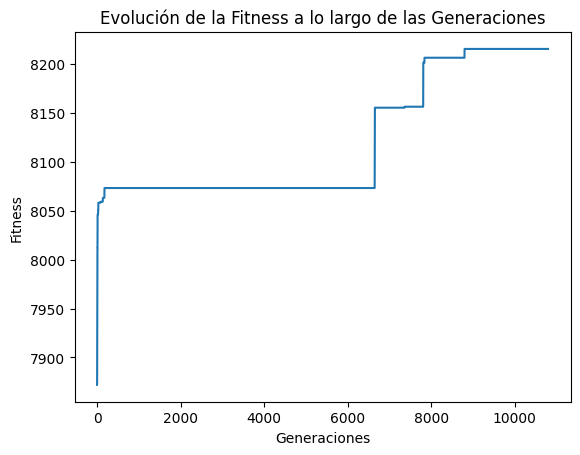

In [ ]:
import matplotlib.pyplot as plt
"""
Muestra la evolución del fitness a lo largo de las generaciones hasta que llega a la mejor solución
"""
first_index = 0
for i in range(len(fitness_history)):
    if fitness_history[i] == best_fitness:
        first_index = i
        break
print(first_index)
plt.plot(fitness_history[15:first_index+2000])
plt.xlabel('Generaciones')
plt.ylabel('Fitness')
plt.title('Evolución de la Fitness a lo largo de las Generaciones')
plt.show()

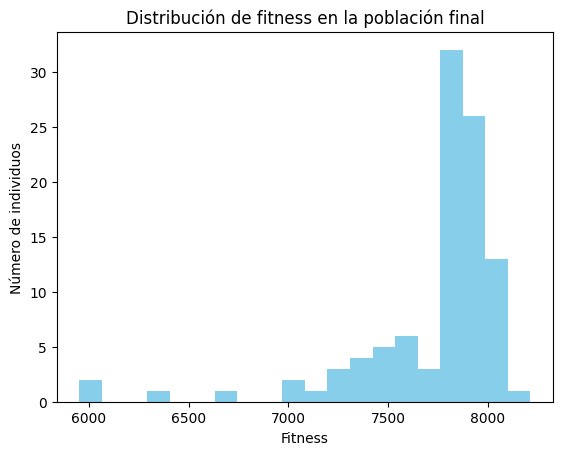

In [ ]:
def plot_fitnesses(fitnesses_final):
  plt.hist(fitnesses_final, bins=20, color='skyblue')
  plt.xlabel('Fitness')
  plt.ylabel('Número de individuos')
  plt.title('Distribución de fitness en la población final')
  plt.show()
fitnesses_final = [fitness(ind) for ind in population]
plot_fitnesses(fitnesses_final)



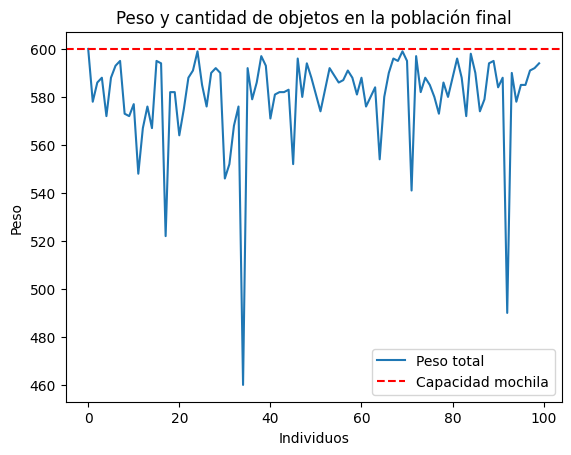

In [ ]:
def plot_peso(peso_history):
  plt.plot(peso_history, label='Peso total')
  plt.axhline(capacidad_mochila, color='red', linestyle='--', label='Capacidad mochila')
  plt.xlabel('Individuos')
  plt.ylabel('Peso')
  plt.title('Peso y cantidad de objetos en la población final')
  plt.legend()
  plt.show()

peso_history = [sum(ind[i]*objetos_peso[i] for i in range(N)) for ind in population]
plot_peso(peso_history)


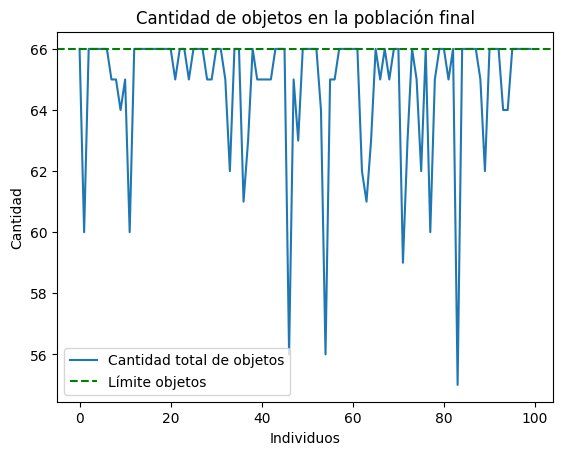

In [ ]:
def plot_cantidad(cantidad_history):
  plt.plot(cantidad_history, label='Cantidad total de objetos')
  plt.axhline(limite_objetos, color='green', linestyle='--', label='Límite objetos')
  plt.xlabel('Individuos')
  plt.ylabel('Cantidad')
  plt.title('Cantidad de objetos en la población final')
  plt.legend()
  plt.show()

cantidad_history = [sum(ind) for ind in population]
plot_cantidad(cantidad_history)




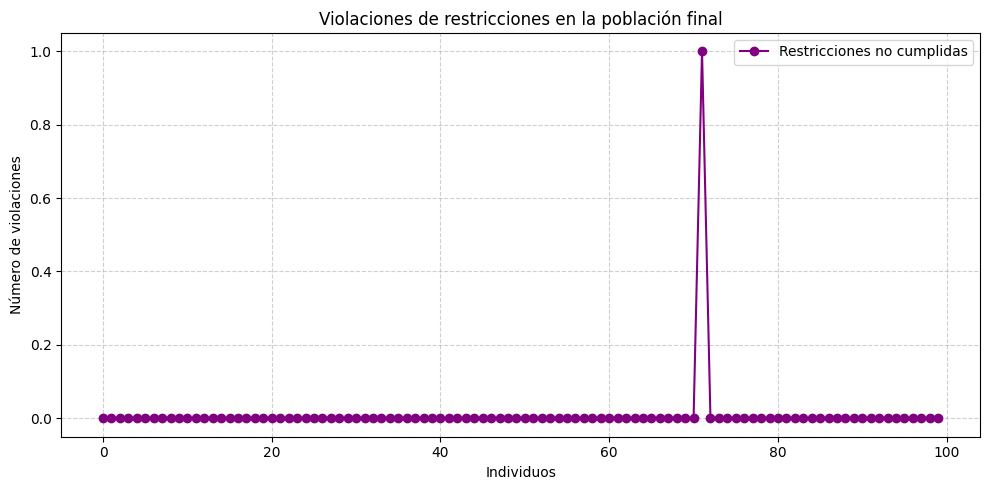

In [ ]:
def plot_violaciones(violaciones_history):
  plt.figure(figsize=(10, 5))
  plt.plot(violaciones_history, marker='o', linestyle='-', color='purple', label='Restricciones no cumplidas')
  plt.xlabel('Individuos')
  plt.ylabel('Número de violaciones')
  plt.title('Violaciones de restricciones en la población final')
  plt.grid(True, linestyle='--', alpha=0.6)
  plt.legend()
  plt.tight_layout()
  plt.show()
violaciones_history = []
for ind in population:
    _, violaciones = validar(ind)
    violaciones_history.append(len(violaciones))
plot_violaciones(violaciones_history)



# Gráficas con los mejores parámetros encontrados con todas las pruebas

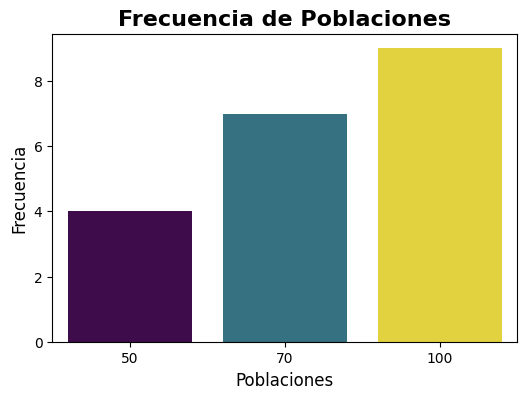

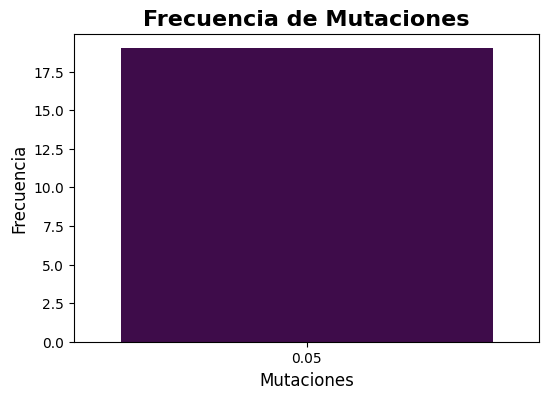

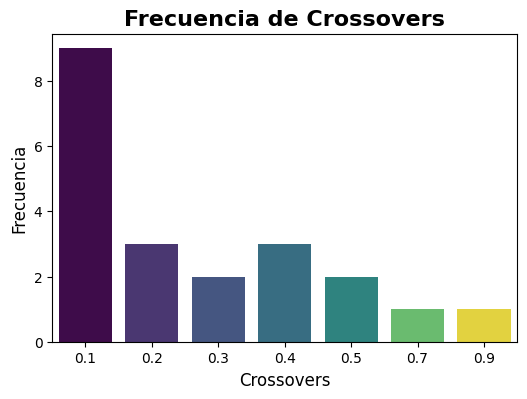

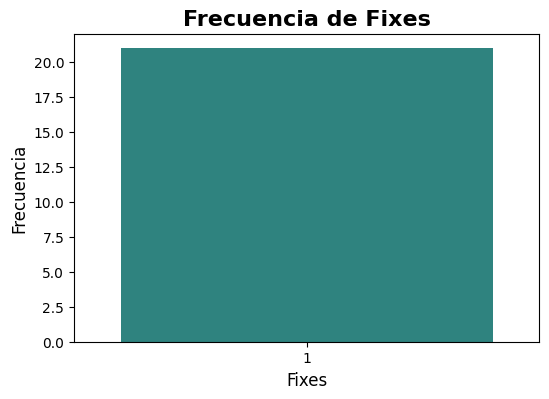

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import seaborn as sns

def plot_frequencies(data, title, xlabel):
    counts = Counter(data)
    keys, values = zip(*counts.items())
    plt.figure(figsize=(6,4))
    sns.barplot(x=list(keys), y=list(values), hue=list(keys), palette="viridis", legend=False)
    plt.title(title, fontsize=16, fontweight="bold")
    plt.xlabel(xlabel, fontsize=12)
    plt.ylabel("Frecuencia", fontsize=12)
    plt.show()

# Graficar cada lista
plot_frequencies(best_populations, "Frecuencia de Poblaciones", "Poblaciones")
plot_frequencies(best_mutations, "Frecuencia de Mutaciones", "Mutaciones")
plot_frequencies(best_crossovers, "Frecuencia de Crossovers", "Crossovers")
plot_frequencies(best_fixes, "Frecuencia de Fixes", "Fixes")
